In [28]:

import numpy as np
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
import time
import sys
import pandas as pd
import scipy
import sympy as sp
from scipy.interpolate import interp1d


import sklearn.gaussian_process as gp
from scipy import stats




sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')
import plot_settings
import importlib
#import multi_exp_log
#import Param_symbol

import GP
import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib


from IPython.display import display, Math

colors = plot_settings.colors()

def import_reload():
    plot_settings.apply()
    importlib.reload(GP)
    importlib.reload(_lib)

COLORS = plot_settings.colors()

import_reload()
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
GP_FIT = GP.GP_process()

In [3]:
RUN_ID = 'new'

DT = 1
Q0 = 17921.57581 
SAVE  = False

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  3.0,
    's':  0.1
    }


LIMS = {
    'R0': (1e-3, 0.1),
    'R1': (5e-3, 0.1),
    'C1': (1e2, 2.5e4),
    'k':  (0.1, 10.0),
    's':  (0.01, 1.0)
    }

VARIABLES = ['R0', 'R1', 'C1']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'µm'
    }
N_VAR = len(VARIABLES)

In [4]:
# Alternaitvely load model as GLOBAL
model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)
history, CONFIG, N_HIDDEN, EPOCHS = load_checkpoint(ckpt)
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def NN_prediction(traj, model = BAT_MODEL, config = CONFIG, ret_elem = False):
    res = predict_np(model,config,traj)
    if ret_elem:
        return res['V'], res['soc'], res['R0'], res['R1'], res['C1'], res['k']
    else:
        return res['V'], res['soc']

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


## ECM solver module

In [ ]:
# Extract expressions from symbolic regression results
def extract_expressions(run_id):
    # Load the symbolic regression results
    elements = ['k', 'R1', 'C1', 'R0', 's']
    
    expressions = {}

    for elem in elements:
    
        results_path = Path(f'sr_models/model_{elem}_{run_id}.csv')
        if not results_path.exists():
            raise FileNotFoundError(f"Results file not found: {results_path}")
    
        results_df = pd.read_csv(results_path)

        expr = results_df['sympy_format'][int(results_df['complexity'].idxmax()*0.65)]# == int(results_df['complexity'].mean())]


        sym_expr = sp.sympify(expr)
        expressions[elem] = sym_expr

        
    
    return expressions['R0'], expressions['R1'], expressions['C1'], expressions['k'],  expressions['s']

print(f"Loading symbolic regression results for RUN_ID: {RUN_ID}")
R0_expr, R1_expr, C1_expr, k_expr, s_expr = extract_expressions(RUN_ID)



R0_func = sp.lambdify(('x0', 'x1', 'x2'), R0_expr, 'numpy')
s_func = sp.lambdify(('x0', 'x1', 'x2'), s_expr, 'numpy')
sdot_func = sp.lambdify(('x0', 'x1', 'x2'), sdot_expr, 'numpy')
k_func = sp.lambdify(('x0', 'x1', 'x2'), k_expr, 'numpy')
R1_func = sp.lambdify(('x0', 'x1', 'x2'), R1_expr, 'numpy')
C1_func = sp.lambdify(('x0', 'x1', 'x2'), C1_expr, 'numpy')


Loading symbolic regression results for RUN_ID: new


In [6]:
display(Math('\\LARGE x_0 = \\mathrm{{C\\,rate}}\\quad x_1 = \\widetilde{d}\\quad x_2 = \\mathrm{{SOC}}'))

display(Math(f'\\LARGE f_{{R_0}}(x_0,x_1,x_2) = {sp.latex(R0_expr)}'))
display(Math(f'\\LARGE f_{{R_1}}(x_0,x_1,x_2)= {sp.latex(R1_expr)}'))
display(Math(f'\\LARGE f_{{C_1}}(x_0,x_1,x_2) = {sp.latex(C1_expr)}'))
display(Math(f'\\LARGE f_k\\,(x_0,x_1,x_2) = {sp.latex(k_expr)}'))
display(Math(f'\\LARGE f_{{s}}(x_0,x_1,x_2) = {sp.latex(s_expr)}'))
print(f'R_0 = {sp.latex(R0_expr)}')
print(f'R_1 = {sp.latex(R1_expr)}')
print(f'C_1 = {sp.latex(C1_expr)}')
print(f'k = {sp.latex(k_expr)}')
print(f's = {sp.latex(s_expr)}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

R_0 = 0.7378943 \tanh{\left(\frac{1.6431527180334 \cdot 10^{-24} x_{0}^{18}}{x_{2}^{18}} \right)} + 0.7004337
R_1 = 0.70177543 + \frac{5.0455837}{\left(\frac{0.14488854 x_{0}}{x_{2}} - 2.9210804\right)^{4} + 0.27494112}
C_1 = x_{2}^{4} \left(\sin{\left(x_{0} - x_{2} \right)} + 13.345381\right)^{4} e^{- 10.6398027252897 x_{2}}
k = e^{0.02696727 {0.65485257}^{x_{1}} + 0.02696727 x_{1} - 0.076874107995696 x_{2}} + 1.318432
s = 2.1683416 - x_{2}


In [7]:
def read_data(file_name, symbolic = True):
    if symbolic:
        df = pd.read_csv(
            f"symbol_data/{file_name}.txt",
            sep=',',
            comment="%"
        )
    else:
        df = pd.read_csv(
            f"{file_name}.txt",
            sep=';',
            comment="%"
        )
    return df


path = f'ecm_node_elements_0429_1012_staged_funcR0_unconstr_pulse_1.32min_32h_1000_0eps'

data = read_data(path)

data['k'] = data['k'] * 100
k_ref = data['k'].mean() 
print(f'k_ref: {k_ref:.5f} GN/mm')
REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k': k_ref}

k_ref: 3.18588 GN/mm


In [8]:
def ECM_solve_du_fix(theta, i, t, RC2 = False, U0 = 0):

    # Create interpolation function ONCE
    I_interp = interp1d(t, i, fill_value="extrapolate")

    def dU1(u, t,R,C):
        I_t = I_interp(t)
        return -u / (R * C) + I_t / C 

    # Solve ODE
    
    U1 = scipy.integrate.odeint(dU1, U0, t, args=(theta[1],theta[2])).flatten()

    if RC2:
        U2 = scipy.integrate.odeint(dU1, U0, t, args=(theta[3],theta[4])).flatten()
    else: 
        U2 = 0
    #U2 = 0

    U = U1 + U2
    # Voltage model
    eta_model =  i*theta[0] + U

    return eta_model

def ECM_solve_curvefit(x, R0, R1, C1):
    t, i = x
    eta_model = ECM_solve_du_fix(theta=[R0, R1, C1], i=i, t=t)
    return eta_model


def parameter_estimation_curvefit(tr, p0=[0.01, 0.01, 1500],lims = LIMS, U0 = 0):
    bounds = ([lims['R0'][0], lims['R1'][0], lims['C1'][0]], [lims['R0'][1], lims['R1'][1], lims['C1'][1]])

    xdata = [tr['t'], tr['I']]
    ydata = -tr['V'] + tr['Ue']
    popt, pcov = scipy.optimize.curve_fit(ECM_solve_curvefit, xdata, ydata, p0=p0, bounds=bounds)
    R0, R1 , C1 = popt
    #print(f"Estimated parameters: R0={R0:.4f} Ohm, R1={R1:.4f} Ohm, C1={C1:.2f} F")
    eta = ECM_solve_curvefit(xdata, R0, R1, C1)
    return -eta + tr['Ue'], tr['t']

In [24]:
import scipy.signal as signal

def R0_calc(C_rate, d_per, SOC, NN = False, REF_VALUES = REF_VALUES, R0_func = R0_func):
    if NN:
        return R0_nn(C_rate, d_per, SOC)
    else:
        return R0_func(C_rate, d_per, SOC) * REF_VALUES['R0']

def R1_calc(C_rate, d_per, SOC,R1_func = R1_func, Ref= REF_VALUES,NN = False):
    if NN:
        return R1_nn(C_rate, d_per, SOC)
    else:
        return R1_func(C_rate, d_per, SOC) * Ref['R1']

def C1_calc(C_rate, d_per, SOC ,C1_func = C1_func, Ref= REF_VALUES, NN = False):
    if NN:
        return C1_nn(C_rate, d_per, SOC)
    else:
        return (C1_func(C_rate, d_per, SOC) * Ref['C1'])

def k_calc(C_rate, d_per, SOC, NN = False, Ref= REF_VALUES, k_func = k_func):
    if NN:
        return k_nn(C_rate, d_per, SOC)
    else:
        return k_func(C_rate, d_per, SOC) * REF_VALUES['k']
    
def sdot_calc(C_rate, d_per, SOC, s, NN = False, Ref= REF_VALUES): #, sdot_func = sdot_func):
    if NN:
        return sdot_nn(C_rate, d_per, SOC, s)
    # else:
    #     return sdot_func(C_rate, d_per, SOC) * Ref['s']


def time_current_profile(C_rate,mode = 'DC'):
    I_0 = C_rate * Q0 / 3600
    if mode == 'DC':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = I_0 * np.ones_like(t)
        return I,t
    elif mode == 'pulse':
        t = np.arange(0, int(3600 / C_rate), DT)
        I = signal.square(2 * np.pi * t / (3600 / C_rate)) * I_0 / 2 + I_0 / 2
        return I,t

def pulse_current_profile(t, C_rate, period = 400):
    I_0 = C_rate * Q0 / 3600
    I = I_0 * (signal.square(2 * np.pi * t / period) + 1)/2
    return I

In [ ]:

def ECM_solve_du(u_par,C_rate, RC2 = False, U0 = 0, discharge = True, mode = 'DC', NN = False, tmax = None, dummy = False, I_profile = None, ret_elem = False):
    
        
    if tmax is not None:
        t = np.arange(0, tmax, DT)
    else:
        t = np.arange(0, 2 * int(3600 / C_rate), DT)
    

    
    
    if discharge:
        print(f"Simulating discharge at C-rate: {C_rate}x")
    else:
        C_rate = -C_rate
        print(f"Simulating charge at C-rate: {C_rate}x")

    if mode == 'pulse':
        def I_interp(t):
            return pulse_current_profile(t, C_rate)
    else:
        i = C_rate * Q0 / 3600 * np.ones_like(t)  # Assuming constant current for simplicity
        I_interp = interp1d(t, i, fill_value="extrapolate")

    i = I_interp(t)
    if not discharge:
        #i = -i
        soc0 = 0
    else:        
        soc0 = 1

    if I_profile is not None and tmax is not None:
        I_interp = interp1d(t, I_profile, fill_value="extrapolate")
        i = I_interp(t)

    print(f"Initial conditions: SOC={soc0}, U1={U0}")
    def dSOC(SOC, t, C_rate=C_rate, u_par=u_par):
        I_t = I_interp(t)
        return -I_t / Q0
    
    
    def SOC(t,SOC0=soc0):
        SOC_t = scipy.integrate.odeint(dSOC, SOC0, t).flatten()
        return SOC_t
    
    SOC_t = SOC(t)
    #plt.show()
    soc_interp = interp1d(t,SOC_t,fill_value=(SOC_t[0], SOC_t[-1]))

    def dU(V_1, t, soc_int = soc_interp, d = u_par, NN = NN):
        I_t = pulse_current_profile(t, C_rate)
        SOC_t = soc_int(t)
        if not discharge:
            SOC_t = 1 - SOC_t
        R = R1_calc(np.abs(C_rate), d, SOC_t, NN = NN)
        C = C1_calc(np.abs(C_rate), d, SOC_t, NN = NN)
        return -V_1 / (R * C) + I_t / C 
    
    def mech(t, soc_int = soc_interp, d = u_par, NN = NN):
        SOC_t = soc_int(t)
        return k_calc(np.abs(C_rate), d, SOC_t, NN = NN)*d

    # Solve ODE
    

    def ECM_system(y, t, u_par, NN = NN):

        SOC, U1 = y
        #if t == 0:
            #print(f"Initial conditions: SOC={SOC}, U1={U1}")

        I_t = I_interp(t)

        if not discharge:

            SOC_eff =  1- SOC

        else:

            SOC_eff = SOC
        if NN:
            R = R1_calc(I_t * 3600/Q0, u_par, SOC_eff, NN = NN)[0]
            C = C1_calc(I_t * 3600/Q0, u_par, SOC_eff, NN = NN)[0]
        else:
            R = R1_calc(I_t * 3600/Q0, u_par, SOC_eff, NN = NN)
            C = C1_calc(I_t * 3600/Q0, u_par, SOC_eff, NN = NN)
        dSOC_dt = -I_t / Q0

        dU1_dt = -U1 / (R * C) + I_t / C

        return [dSOC_dt, dU1_dt]

    #U1 = scipy.integrate.odeint(dU, U0, t).flatten()
    y0 = [soc0, U0]

    sol = scipy.integrate.odeint(ECM_system, y0, t, args=(u_par,))
    #sol_full = scipy.integrate.solve_ivp(lambda t, y: ECM_system(y, t, u_par, NN), [t[0], t[-1]], y0, t_eval=t)
    # solve with euler method for better control
    #sol = np.zeros((len(t), 2))
    #sol[0, :] = y0
    #for idx in range(1, len(t)):
        # sol[idx, :] = sol[idx-1, :] + np.array(ECM_system(sol[idx-1, :], t[idx-1], u_par, NN=NN)) * DT
    #sol = sol_full.y.T
    SOC_t = sol[:, 0]

    U1 = sol[:, 1]

    U = U1 #+ U2
    # Voltage model
    R0_vals = []
    #for s in SOC_t:
    R0_vals = R0_calc(i * 3600/Q0,u_par,SOC_t, NN = NN)
    eta_model = i * np.array(R0_vals) + U
    V_B = GP.soc_to_Ue(SOC_t, GP_FIT) - eta_model


    if not discharge:
        valid_inds = V_B< 5.5
    else:
        valid_inds_soc = (SOC_t < 1.0) & (SOC_t > 0.0)
        valid_inds_V = (V_B < 5.5) & (V_B > 2.3)
        valid_inds = valid_inds_soc & valid_inds_V

    
    V_B = V_B[valid_inds]
    t = t[valid_inds]
    soc = SOC_t[valid_inds]
    Ue = GP.soc_to_Ue(soc, GP_FIT)
    i = I_interp(t)
    # save array of r0 r1 c1
    R0_list = R0_calc(i *3600/Q0,u_par,soc, NN = NN)
    R1_list = R1_calc(i *3600/Q0, u_par, soc, NN = NN)
    C1_list = C1_calc(i * 3600/Q0, u_par, soc, NN = NN) 

    if not ret_elem:
        return V_B,soc, Ue,i ,t#, mech(t)
    else:
        return V_B,soc, Ue,i ,t, R0_list, R1_list, C1_list




def ECM_solve_du(u_par, C_rate, i = None, discharge = True, mode = 'DC', NN = False, tmax = None, dummy = False, I_profile = None, soc_init = None):
        u_par = u_par
        if tmax is not None:
            t = np.arange(0, tmax, DT)
        else:
            t = np.arange(0, 1 * int(3600 / C_rate), DT)
        if i is None:
             i = C_rate * Q0 / 3600 * np.ones_like(t)  # Assuming constant current for simplicity

        if mode == 'pulse':
            i = pulse_current_profile(t, C_rate)

        if I_profile is not None and tmax is not None:
            #I_interp = interp1d(t, I_profile, fill_value="extrapolate")
            i = I_profile
             
        
        soc = np.zeros_like(i)
        if discharge:
            soc[0] = 1
        else:
            soc[0] = 0

        if soc_init is not None:
            soc[0] = soc_init
        U = np.zeros_like(i)
        U[0] = 0
        for k in range(len(i)-1):
            

            soc[k+1] = soc[k] - i[k] / Q0 * DT
            if NN:
                 R = R1_calc(i[k] * 3600/Q0, u_par, soc[k], NN = NN)[0]
                 C = C1_calc(i[k] * 3600/Q0, u_par, soc[k], NN = NN)[0]
            else:
                R = R1_calc(i[k] * 3600/Q0, u_par, soc[k], NN = NN)
                C = C1_calc(i[k] * 3600/Q0, u_par, soc[k], NN = NN)
            U[k+1] = (U[k] + DT * i[k] / C) / (1.0 + DT / (R * C))
        
        
        
        eta_model = i * R0_calc(i[k] * 3600/Q0,u_par,soc, NN = NN) + U
        V_B = GP.soc_to_Ue(soc, GP_FIT) - eta_model

        return V_B, soc, GP.soc_to_Ue(soc, GP_FIT), i, t

def EMM_solve_ds(u_par, C_rate, i = None, discharge = True, mode = 'DC', NN = False, tmax = None, dummy = False, I_profile = None, soc_init = None):
        u_par = u_par
        if tmax is not None:
            t = np.arange(0, tmax, DT)
        else:
            t = np.arange(0, 1 * int(3600 / C_rate), DT)
        if i is None:
             i = C_rate * Q0 / 3600 * np.ones_like(t)  # Assuming constant current for simplicity

        if mode == 'pulse':
            i = pulse_current_profile(t, C_rate)

        if I_profile is not None and tmax is not None:
            #I_interp = interp1d(t, I_profile, fill_value="extrapolate")
            i = I_profile
             
        
        soc = np.zeros_like(i)
        if discharge:
            soc[0] = 1
        else:
            soc[0] = 0
        if soc_init is not None:
            soc[0] = soc_init

        s = np.zeros_like(i)
        s[0] = 0
        for k in range(len(i)-1):
            
            soc[k+1] = soc[k] - i[k] / Q0 * DT
            if NN:
                sdot = sdot_calc(i[k] * 3600/Q0, u_par, soc[k], s[k], NN = NN)
            # else:
            #     sdot = sdot_calc(i[k] * 3600/Q0, u_par, soc[k], s[k], NN = NN)
            s[k+1] = s[k] + sdot * DT
        
        
        F = k_calc(i[k] * 3600/Q0, u_par, soc, NN = NN) * (u_par - s)

        return F, soc, i, t
    

#V, soc, Ue, i, t, R0_est, R1_est, C1_est = ECM_solve_du(30, 2, discharge = True, mode = 'DC', NN = True, ret_elem = True)

In [11]:
# f, ax = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
# V, soc, Ue, i, t, R0_est, R1_est, C1_est = ECM_solve_du(0, 1, discharge = True, mode = 'DC', NN = True)
# ax[1].plot(soc,  C1_est * R1_est, label='R0')
# ax[0].plot(soc, V, label='Voltage')
# V, soc, Ue, i, t, R0_est, R1_est, C1_est = ECM_solve_du(0, 2, discharge = True, mode = 'DC', NN = True)
# ax[1].plot(soc, C1_est * R1_est, label='R0', color = COLORS[1])
# ax[0].plot(soc, V, label='Voltage', color = COLORS[1])
# ax[1].set_xlabel('Time (s)')
# ax[0].set_ylabel('Voltage (V)')
# ax[0].legend()

In [12]:
# V_B,soc,Ue,i,t = ECM_solve_du(1,2, discharge=True, NN = True, mode = 'DC')

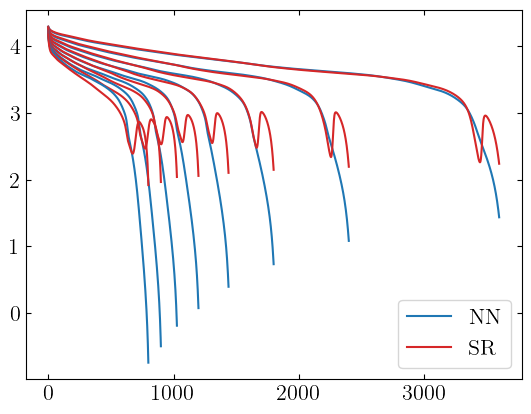

In [13]:

for j,C_rate in enumerate(np.arange(1, 5, 0.5)):
    if j == 0:
        label_NN = 'NN'
        label_SR = 'SR'
    else:        
        label_NN = None
        label_SR = None
    V_B,soc,Ue,i,t = ECM_solve_du(1,C_rate, discharge=True, NN = True, mode = 'DC')
    plt.plot(t, V_B, label=label_NN, color = COLORS[0])
    V_B,soc,Ue,i,t = ECM_solve_du(1,C_rate, discharge=True, NN = False, mode = 'DC')
    plt.plot(t, V_B, label=label_SR, color = COLORS[1])
#plt.plot(np.linspace(0,1,100), GP.soc_to_Ue(np.linspace(0,1,100), GP_FIT), color = 'k',ls = '--', label='True $U_e$')
plt.legend()

plt.show()

# for u in np.arange(1, 29, 5):
#     V_B,soc,Ue,i,t,F = ECM_solve_du(u,2)
#     plt.scatter(u, F.min(), label=f'u={u}')
#     plt.scatter(u, F.max(), label=f'u={u}')


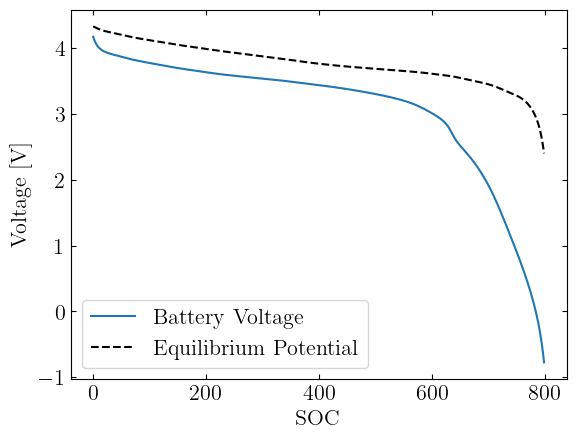

In [14]:
C = 4.5;u = 10
V_B,soc,Ue,i,t = ECM_solve_du(u,C, discharge = True, mode = 'DC', NN = True)
f, ax = plt.subplots()
#ax2 = ax.twinx()
#ax2.plot(t, i, label='Mechanical Force', color = 'tab:red', alpha = 0.5)
#ax.plot(t, V_B, label='Battery Voltage') 
ax.plot(t, V_B, label='Battery Voltage') 
ax.plot(t,Ue, 'black', ls = '--',label='Equilibrium Potential')
ax.set_xlabel('SOC')
#ax2.plot(t, soc, color = 'tab:red', label='SOC')
ax.set_ylabel('Voltage [V]')
ax.legend()

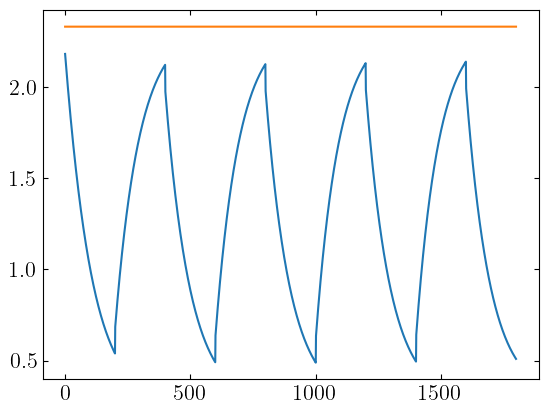

In [15]:
V_B,soc,Ue,i,t = ECM_solve_du(1,2, discharge = False, mode = 'pulse', NN = True)
f, ax = plt.subplots()

#ax2.plot(t, i, label='Mechanical Force', color = 'tab:red', alpha = 0.5)
ax.plot(t, V_B, label='Battery Voltage') 
ax.plot(t, Ue, label='Battery Voltage') 

#plt.plot(t, soc, label=f'C={C_rate}x')

In [16]:
df_true = read_data('combo_half', symbolic=False)
display(df_true.head())
split_train = int(df_true['trajectory'].max() * 0.8)

df_test = df_true[df_true['trajectory'] >= split_train]
df_train = df_true[df_true['trajectory'] < split_train]

print(f'F_max in test set: {df_true["F"][df_true['t'] == 0].max():.2f} ') 

#df_test_DC = df_test[df_test['pulse'] == False]
#df_train_DC = df_train[df_train['pulse'] == False]
df_dc = df_train[df_train['pulse'] == False]

,u_par,C,t,V,F,u,Ue,soc,I,eta,pulse,trajectory
0,19.3,3.0,0,4.257546,0.079618,-2.774037,4.324997,0.999999,7.467323,0.067452,True,0
1,19.3,3.0,1,4.174033,0.079630,-2.774037,4.322476,0.999171,14.934647,0.148443,True,0
2,19.3,3.0,2,4.155347,0.079641,-2.774037,4.319938,0.998338,14.934647,0.164591,True,0
3,19.3,3.0,3,4.145744,0.079652,-2.774037,4.317401,0.997504,14.934647,0.171657,True,0
4,19.3,3.0,4,4.137439,0.079664,-2.774037,4.314863,0.996671,14.934647,0.177425,True,0


F_max in test set: 0.14 


Trajectories in test set: 
[  2   4   8  10  14  16  26  28  30  32  34  38  42  44  52  56  60  62
  80  82  90  92  94  96 102 104 106 108 110 112 116 118 120 124 128 130
 132 136 138 140 142 144 146 156 160 162 168]
33
Selected trajectory: 33 with C=4.22 and u_par=4.1
31
Selected trajectory: 31 with C=4.5 and u_par=20.1


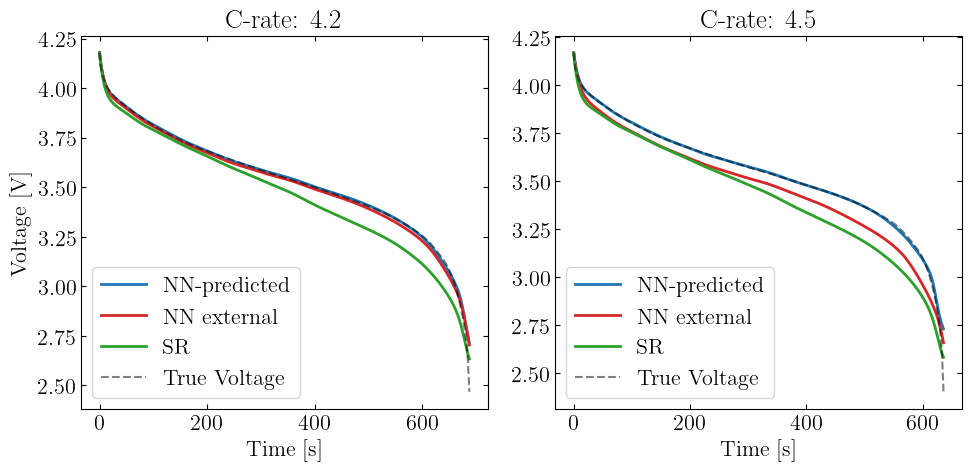

In [26]:


#plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o')

print(f'Trajectories in test set: ')


df = df_dc
print(df['trajectory'].unique())
trajs = prepare_data(df)
u_C_pairs = df.loc[df['t'] == 0, ['u_par', 'C', 'trajectory']]

f,ax = plt.subplots(1,2, figsize=(10,5))

for j,C in enumerate([4.2, 4.5]):

    traj = int(np.argmin(np.abs(u_C_pairs['C'] - C))) 
    print(traj)
    C_ext = trajs[traj]['C']
    u_par_ext = trajs[traj]['u_per']
    soc_init = trajs[traj]['soc'][0]
    print(f"Selected trajectory: {traj} with C={C_ext} and u_par={u_par_ext}")
    # C_ext = u_C_pairs.loc[u_C_pairs['trajectory'] == traj, 'C'].values[0]
    # u_par_ext = u_C_pairs.loc[u_C_pairs['trajectory'] == traj, 'u_par'].values[0]
    # i= df_test.loc[df_test['trajectory'] == traj, 'I'].values
    #print(len(i))
    #ax[j].plot(df_test.loc[df_test['trajectory'] == traj, 't'], df_test.loc[df_test['trajectory'] == traj, 'V'], label='True Voltage', color = 'k', ls = '--')
    #tmax = df_test.loc[df_test['trajectory'] == traj, 't'].max()
    #print(f"Selected trajectory parameters: C={C_ext}, u_par={u_par_ext} tmax = {tmax:.2f}s")
    
    #V_B,soc,Ue,i,t = ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'DC', tmax = df_test.loc[df_test['trajectory'] == traj, 't'].max()+1, I_profile = i)
    #ax[j].plot(soc, V_B, label='SR Voltage')
    traj_full = trajs[traj]
    t_max = traj_full['T']
    t_traj = np.arange(0, t_max, DT)
    V_B, soc = NN_prediction(traj_full)


    ax[j].plot(t_traj, V_B, label='NN-predicted', lw = 2, color = COLORS[0])
    i = traj_full['I'] * np.ones_like(t_traj)

    V_B,soc,Ue,i,t= ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'DC', NN = True, tmax =t_max, I_profile = i, soc_init = soc_init)


    ax[j].plot(t, V_B, label='NN external', lw = 2, color = COLORS[1])


    V_B,soc,Ue,i,t= ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'DC', NN = False, tmax =t_max, I_profile = i, soc_init = soc_init)

    ax[j].plot(t, V_B, label='SR', lw = 2, color = COLORS[2])
    ax[j].plot(t_traj,traj_full['V'], label='True Voltage', color = 'k', ls = '--', alpha = .5)


    #V_B_fix, t = parameter_estimation_curvefit(df_test.loc[df_test['trajectory'] == traj])
    #ax[j].plot(soc, V_B_fix, label='Fix ECM')
#plt.plot(t, Ue, label='Equilibrium Potential', color = 'k', ls = '--')

#VB_fix, t = parameter_estimation_curvefit(df_true.loc[df_true['trajectory'] == traj])
#plt.plot(t, VB_fix, label='Curvefit ECM')
#plt.plot(t[:len(df_true.loc[df_true['trajectory'] == traj, 't'])], V_B[:len(df_true.loc[df_true['trajectory'] == traj, 't'])], label='NN Voltage')
    ax[j].set_xlabel('Time [s]')
    ax[j].set_title(f'C-rate: {C_ext:.1f}')
    ax[j].legend()
ax[0].set_ylabel('Voltage [V]')

# ax[2].plot(t,soc, label='SOC', color = 'tab:red')
# ax[2].plot(df_test.loc[df_test['trajectory'] == traj, 't'], df_test.loc[df_test['trajectory'] == traj, 'soc'], label='True Voltage', color = 'k', ls = '--')
plt.tight_layout()
# plt.savefig('ecm_fit.pdf')

Trajectories in test set: 
[  2   4   8  10  14  16  26  28  30  32  34  38  42  44  52  56  60  62
  80  82  90  92  94  96 102 104 106 108 110 112 116 118 120 124 128 130
 132 136 138 140 142 144 146 156 160 162 168]
33
Selected trajectory: 33 with C=4.22 and u_par=4.1


IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

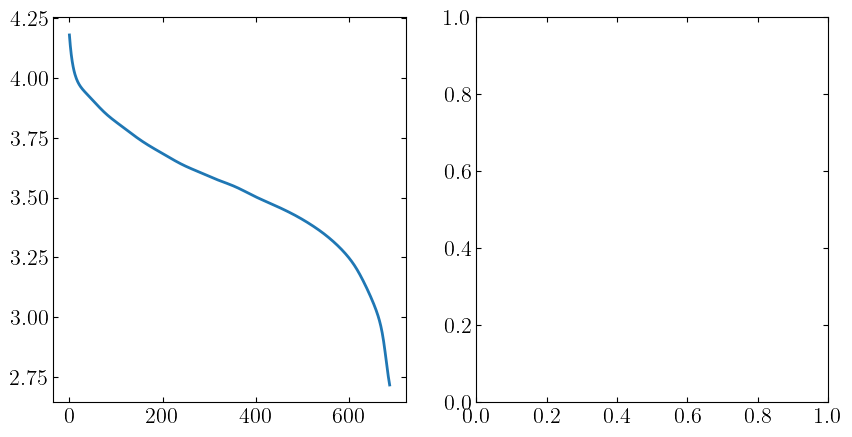

In [29]:

print(f'Trajectories in test set: ')
df = df_dc
print(df['trajectory'].unique())
trajs = prepare_data(df)
u_C_pairs = df.loc[df['t'] == 0, ['u_par', 'C', 'trajectory']]

f,ax = plt.subplots(1,2, figsize=(10,5))

for j,C in enumerate([4.2, 4.5]):

    traj = int(np.argmin(np.abs(u_C_pairs['C'] - C))) 
    print(traj)
    C_ext = trajs[traj]['C']
    u_par_ext = trajs[traj]['u_per']
    soc_init = trajs[traj]['soc'][0]
    print(f"Selected trajectory: {traj} with C={C_ext} and u_par={u_par_ext}")

    traj_full = trajs[traj]
    t_max = traj_full['T']
    t_traj = np.arange(0, t_max, DT)
    V_B, soc = NN_prediction(traj_full)


    ax[j].plot(t_traj, V_B, label='NN-predicted', lw = 2, color = COLORS[0])
    i = traj_full['I'] * np.ones_like(t_traj)

    V_B,soc,Ue,i,t= EMM_solve_ds(u_par_ext,C_ext, discharge = True, mode = 'DC', NN = True, tmax =t_max, I_profile = i, soc_init = soc_init)


    ax[j].plot(t, V_B, label='NN external', lw = 2, color = COLORS[1])


    # V_B,soc,Ue,i,t= EMM_solve_ds(u_par_ext,C_ext, discharge = True, mode = 'DC', NN = False, tmax =t_max, I_profile = i, soc_init = soc_init)

    ax[j].plot(t, V_B, label='SR', lw = 2, color = COLORS[2])
    ax[j].plot(t_traj,traj_full['V'], label='True Voltage', color = 'k', ls = '--', alpha = .5)
    ax[j].set_xlabel('Time [s]')
    ax[j].set_title(f'C-rate: {C_ext:.1f}')
    ax[j].legend()
ax[0].set_ylabel('Voltage [V]')

# ax[2].plot(t,soc, label='SOC', color = 'tab:red')
# ax[2].plot(df_test.loc[df_test['trajectory'] == traj, 't'], df_test.loc[df_test['trajectory'] == traj, 'soc'], label='True Voltage', color = 'k', ls = '--')
plt.tight_layout()
# plt.savefig('ecm_fit.pdf')

Number of trajectories in pulse dataset before filtering: 75
75
Number of trajsectories in pulse dataset: 75
Selected trajectory index: 54
Selected trajectory parameters: C=5.0, u_par=15.6 tmax = 11.00s


Text(0, 0.5, 'Voltage [V]')

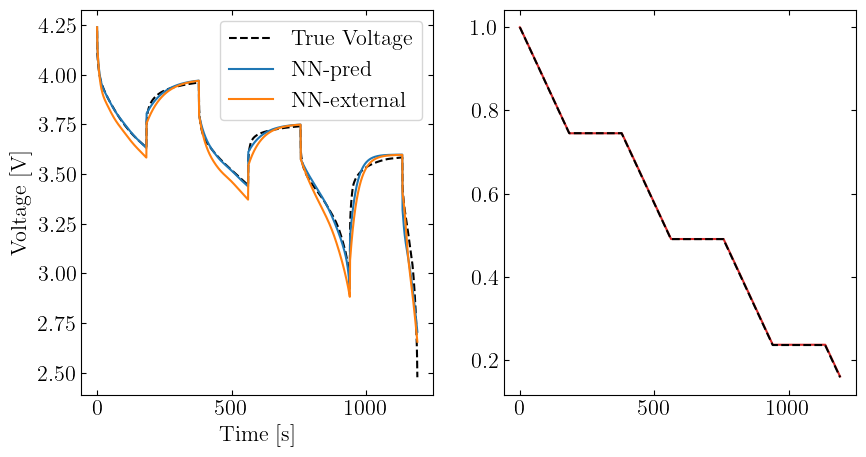

In [18]:
df_pulse = read_data('merged_pulse_hyper', symbolic=False)
#split_pulse = int(df_pulse['trajectory'].max() * 0.8)
#df_pulse_train = df_pulse[df_pulse['trajectory'] < split_pulse]

print(f"Number of trajectories in pulse dataset before filtering: {df_pulse['trajectory'].nunique()}")
#df_pulse = df_pulse[df_pulse['trajectory'] >= int(split_pulse * 0.8)]

print(len(df_pulse['trajectory'].unique()))

uc_pulse_pairs = df_pulse.loc[df_pulse['t'] == 0, ['u_par', 'C', 'trajectory']]
trajs_pulse = prepare_pulse_data(df_pulse)

C = 5; u = 9.9
traj = int(np.argmin(np.abs(uc_pulse_pairs['C'] - C))) 



print(f'Number of trajsectories in pulse dataset: {df_pulse["trajectory"].nunique()}')
C_ext = uc_pulse_pairs.loc[uc_pulse_pairs['trajectory'] == traj, 'C'].values[0]
u_par_ext = uc_pulse_pairs.loc[uc_pulse_pairs['trajectory'] == traj, 'u_par'].values[0]
i = df_pulse.loc[df_pulse['trajectory'] == traj, 'I'].values

print(f"Selected trajectory index: {traj}")

f, ax = plt.subplots(1,2, figsize=(10,5))
traj_full = trajs_pulse[traj]
#ax[0].plot(df_pulse.loc[df_pulse['trajectory'] == traj, 't'], df_pulse.loc[df_pulse['trajectory'] == traj, 'V'], label='True Voltage', color = 'k', ls = '--')
ax[0].plot(traj_full['t'], traj_full['V'], label='True Voltage', color = 'k', ls = '--')
tmax = len(traj_full)#df_pulse.loc[df_pulse['trajectory'] == traj, 't'].max()
print(f"Selected trajectory parameters: C={C_ext}, u_par={u_par_ext} tmax = {tmax:.2f}s")
VB, soc = NN_prediction(trajs_pulse[traj])
ax[0].plot(traj_full['t'], VB, label='NN-pred')
VB, soc,Ue,i,t = ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'DC', tmax = df_pulse.loc[df_pulse['trajectory'] == traj, 't'].max()+1, I_profile = i, NN = True)
ax[0].plot(t, VB, label='NN-external')
#VB, soc,Ue,i,t = ECM_solve_du(u_par_ext,C_ext, discharge = True, mode = 'pulse', NN = True, tmax = df_pulse.loc[df_pulse['trajectory'] == traj, 't'].max())
#plt.plot(t, VB, label='NN Voltage')
#R1 = R1(np.abs(C_ext), u_par_ext/100, soc, NN = True)
#ax[1].plot(t, R1, label='R1', color = 'tab:blue')
ax[0].legend()
ax[1].plot(t, soc, label='Current Profile', color = 'tab:red')
ax[1].plot(df_pulse.loc[df_pulse['trajectory'] == traj, 't'], df_pulse.loc[df_pulse['trajectory'] == traj, 'soc'], label='Current Profile', color = 'black', ls = '--')
#VB_fix, soc = parameter_estimation_curvefit(df_pulse.loc[df_pulse['trajectory'] == traj])
#ax[0].plot(t, VB_fix, label='Fix ECM', color = 'tab:green')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Voltage [V]')

In [19]:
def scale(df = df_true, variables = ['V','F']):
    scaled_df = df.copy()
    range_val = {}
    for var in variables:
        min_val = df[var].min()
        max_val = df[var].max()
        range_val[var] = (max_val - min_val)
    return range_val


def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    #mae = np.mean(np.abs(y_true - y_pred))
    #r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    return rmse

def simulate_and_evaluate(df):
    scaling = scale()
    N = df['trajectory'].nunique()
    rmse_SR = np.zeros((N,2))
    rmse_NN = np.zeros((N,2))
    rmse_fix = np.zeros(N)
    obs_inpt = np.zeros((N,2))
    V_true_all = []
    F_true_all = []
    V_pred_SR_all = []
    F_pred_SR_all = []
    V_pred_NN_all = [] 
    F_pred_NN_all = []
    V_pred_fix_all = []
    for i in trange(N):
        traj = i + split_train
        V_true = df.loc[df['trajectory'] == traj, 'V'].values
        F_true = df.loc[df['trajectory'] == traj, 'F'].values

        #print(f"Evaluating trajectory {traj} with {len(V_true)} data points.")

        C = df.loc[df['trajectory'] == traj, 'C'].values[0]
        u_par = df.loc[df['trajectory'] == traj, 'u_par'].values[0]

        obs_inpt[i,0] = C
        obs_inpt[i,1] = u_par

        V_B_NN,_,_,_,_ = ECM_solve_du(u_par,C, discharge = True, mode = 'DC', NN = True, tmax=len(V_true) , dummy = False)
        V_B, _,_,_,_ = ECM_solve_du(u_par,C, discharge = True, mode = 'DC', NN = False, tmax=len(V_true), dummy = False)
        V_B_fix,_ = parameter_estimation_curvefit(df.loc[df['trajectory'] == traj])
        #n = min(len(V_true), len(V_B), len(V_B_NN))
        
        #V_true = V_true[:n]

        #F_true = F_true[:n]

        #V_B = V_B[:n]

        #F = F[:n]

        #V_B_NN = V_B_NN[:n]

        #F_NN = F_NN[:n]

        #print(f'lengths: V_true={len(V_true)}, F_true={len(F_true)}, V_B={len(V_B)}, F={len(F)}, V_B_NN={len(V_B_NN)}, F_NN={len(F_NN)}')
        #Y_true = np.concatenate((V_true, F_true))
        #Y_pred_NN = np.concatenate((V_B_NN, F_NN))
        #Y_pred = np.concatenate((V_B, F))  
        rmse_fix[i] = metrics(V_true, V_B_fix) / scaling['V']
        rmse_SR[i,0] = metrics(V_true, V_B) / scaling['V']
        rmse_NN[i,0] = metrics(V_true, V_B_NN) / scaling['V']
        V_true_all.append(V_true)
        F_true_all.append(F_true)
        V_pred_SR_all.append(V_B)
        V_pred_NN_all.append(V_B_NN)
        V_pred_fix_all.append(V_B_fix)
    return rmse_SR, rmse_NN, rmse_fix, obs_inpt, V_true_all,  V_pred_SR_all,  V_pred_NN_all, V_pred_fix_all

In [20]:
rmse_SR, rmse_NN, rmse_fix,obs_inpt,V_true, V_pred_SR, V_pred_NN,V_pred_fix = simulate_and_evaluate(df_test)

  0%|          | 0/22 [00:00<?, ?it/s]


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
plt.scatter(obs_inpt[:,0], rmse_NN[:,0])
plt.scatter(obs_inpt[:,0], rmse_SR[:,0])
plt.scatter(obs_inpt[:,0], rmse_fix[:])

In [ ]:
avg_Nrmse_NN_V = np.mean(rmse_NN[:,0])
avg_Nrmse_NN_F = np.mean(rmse_NN[:,1])
avg_Nrmse_SR_V = np.mean(rmse_SR[:,0])
avg_Nrmse_SR_F = np.mean(rmse_SR[:,1])
avg_Nrmse_fix_V = np.mean(rmse_fix)
rmse_fix_V = np.vstack((rmse_fix, np.zeros_like(rmse_fix))).T   



print(rmse_fix_V.shape, rmse_NN.shape, rmse_SR.shape)

In [ ]:
metric_names = ['Voltage', 'Force']
methods = ['SR', 'NN', 'Fix']

bar_plot_dict = {
    'NN Voltage': avg_Nrmse_NN_V,
    'NN Force': avg_Nrmse_NN_F,
    'SR Voltage': avg_Nrmse_SR_V,
    'SR Force': avg_Nrmse_SR_F,
    'Fix Voltage': avg_Nrmse_fix_V,
    'Fix Force': np.zeros_like(avg_Nrmse_fix_V)
}

n_methods = len(methods)
n_metrics = len(metric_names)

fig, ax = plt.subplots(
    1,
    n_metrics,
    figsize=(4 * n_metrics, 4),
    sharey=False
)

# Handle single subplot case
if n_metrics == 1:
    ax = [ax]

for j, metric in enumerate(metric_names):

    # Collect values dynamically from dictionary
    vals = []

    for method in methods:
        key = f'{method} {metric}'
        vals.append(np.mean(bar_plot_dict[key]))

    bars = ax[j].bar(
        methods,
        vals,
        color=[COLORS[i % len(COLORS)] for i in range(n_methods)], alpha = 0.9, edgecolor='black', linewidth=.5
    )

    ax[j].set_title(metric)
    ax[j].set_ylabel('NRMSE')
    ax[j].set_ylim(0, max(vals) * 1.2)
    # add error bars for min and max in the rmse values across trajectories

    # ax[j].errorbar(
    #     methods,
    #     vals,
    #     yerr=[np.min(vals), np.max(vals)],
    #     fmt='none',
    #     ecolor='black',
    #     capsize=5
    # )
    # 
    # for b in bars:
    #     h = b.get_height()
    #     ax[j].text(
    #         b.get_x() + b.get_width() / 2,
    #         h,
    #         f'{h:.3f}',
    #         ha='center',
    #         va='bottom',
    #         fontsize=9
    #     )

plt.tight_layout()
plt.show()